# 02 — Frozen internal test, robustness, and final interpretation

This notebook reads the immutable terminal evaluation of the validation-selected FFT ResNet-50 (representative seed 17). It does not train, tune a threshold, replace a checkpoint, or select a representation. Clean and degradation results were generated in one predeclared stage. External Synthbuster + RAISE validation has not been materialised and is kept explicitly separate.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_repository_root() -> Path:
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'src/ai_image_detector').is_dir():
            return candidate
    raise RuntimeError('Run the notebook from this repository or a child directory.')


REPO = find_repository_root()
EVALUATION = REPO / 'artifacts/evaluations/dani_fft_seed17_internal_test_v1'
CONFIG = EVALUATION / 'internal_test_evaluation.json'
METRICS = EVALUATION / 'internal_test_metrics.csv'
PREDICTIONS = EVALUATION / 'internal_test_predictions.csv'
config = json.loads(CONFIG.read_text(encoding='utf-8'))
metrics = pd.read_csv(METRICS)
predictions = pd.read_csv(PREDICTIONS)

assert config['evaluation_status'] == 'completed_no_post_test_tuning'
assert config['selection_record']['internal_test_metrics_used_for_selection'] is False
assert config['model']['representation'] == 'fft'
assert config['model']['device'] == 'mps'
assert len(predictions) == 1110 * 7
assert predictions['checkpoint_sha256'].nunique() == 1
assert predictions['threshold'].nunique() == 1
pd.Series({
    'status': config['evaluation_status'],
    'representation': config['model']['representation'],
    'device': config['model']['device'],
    'threshold': config['model']['validation_selected_threshold'],
    'prediction_rows': len(predictions),
})

status             completed_no_post_test_tuning
representation                               fft
device                                       mps
threshold                               0.822677
prediction_rows                             7770
dtype: object

## 1. Clean locked-test result

The operating threshold 0.8226768 was selected on validation and applied unchanged. Confidence intervals resample all five rows of a parent group together, preserving the dependence between one real photograph and its four generated counterparts.

In [2]:
clean = metrics.query("condition == 'clean' and scope == 'all'").iloc[0]
clean_table = pd.DataFrame({
    'metric': ['ROC-AUC', 'Balanced accuracy', 'Macro-F1', 'FPR@TPR95'],
    'estimate': [clean.roc_auc, clean.balanced_accuracy, clean.macro_f1, clean.fpr_at_tpr_95],
    'ci_lower': [clean.roc_auc_ci_lower, clean.balanced_accuracy_ci_lower, clean.macro_f1_ci_lower, clean.fpr_at_tpr_95_ci_lower],
    'ci_upper': [clean.roc_auc_ci_upper, clean.balanced_accuracy_ci_upper, clean.macro_f1_ci_upper, clean.fpr_at_tpr_95_ci_upper],
})
display(clean_table)
pd.Series({
    'true_negative': int(clean.tn),
    'false_positive': int(clean.fp),
    'false_negative': int(clean.fn),
    'true_positive': int(clean.tp),
    'ECE_15': clean.ece_15,
    'Brier': clean.brier,
})

,metric,estimate,ci_lower,ci_upper
0,ROC-AUC,0.893941,0.871820,0.916324
1,Balanced accuracy,0.826014,0.800676,0.851351
2,Macro-F1,0.774670,0.752255,0.798899
3,FPR@TPR95,0.409910,0.337838,0.472973


true_negative     181.000000
false_positive     41.000000
false_negative    145.000000
true_positive     743.000000
ECE_15              0.030147
Brier               0.089432
dtype: float64

## 2. Generator-stratified clean results

Every row compares all 222 real images with the 222 images from one declared generator condition. The gap between T2I and I2I/TI2I conditions is a material limitation hidden by the aggregate score.

In [3]:
generator_clean = metrics.query("condition == 'clean' and scope == 'real_vs_generator'").copy()
display(generator_clean[[
    'generator', 'roc_auc', 'balanced_accuracy', 'macro_f1', 'fpr_at_tpr_95',
    'roc_auc_ci_lower', 'roc_auc_ci_upper', 'balanced_accuracy_ci_lower',
    'balanced_accuracy_ci_upper'
]].sort_values('balanced_accuracy', ascending=False))

,generator,roc_auc,balanced_accuracy,macro_f1,fpr_at_tpr_95,roc_auc_ci_lower,roc_auc_ci_upper,balanced_accuracy_ci_lower,balanced_accuracy_ci_upper
3,SD_XL:T2I,0.962747,0.896396,0.895711,0.108108,0.942981,0.980379,0.867117,0.923423
1,Dalle3:T2I,0.947772,0.889640,0.889027,0.157658,0.925691,0.967354,0.862613,0.916667
4,SD_XL:TI2I,0.832948,0.763514,0.762877,0.509009,0.802054,0.865008,0.727477,0.801802
2,SD_XL:I2I,0.832299,0.754505,0.753593,0.481982,0.799343,0.865335,0.720721,0.790541


## 3. Predeclared robustness conditions

Robustness values reuse the same frozen checkpoint and validation threshold. JPEG, resize, and blur rows are not averaged into the clean result. FPR@TPR95 is descriptive for each condition's score ordering; it does not replace the fixed operating threshold.

,condition,roc_auc,balanced_accuracy,macro_f1,fpr_at_tpr_95,real_recall,ai_recall,delta_bacc_from_clean
0,clean,0.893941,0.826014,0.774670,0.409910,0.815315,0.836712,0.000000
5,jpeg_q95,0.822234,0.716779,0.736664,0.549550,0.500000,0.933559,-0.109234
10,jpeg_q75,0.723521,0.559685,0.561415,0.765766,0.144144,0.975225,-0.266329
15,jpeg_q50,0.698736,0.518581,0.484081,0.792793,0.040541,0.996622,-0.307432
20,resize_075,0.380828,0.476914,0.447567,0.986486,0.027027,0.926802,-0.349099
25,resize_050,0.416144,0.478604,0.262398,0.981982,0.833333,0.123874,-0.347410
30,gaussian_blur_r1,0.430051,0.453829,0.362177,0.986486,0.585586,0.322072,-0.372185


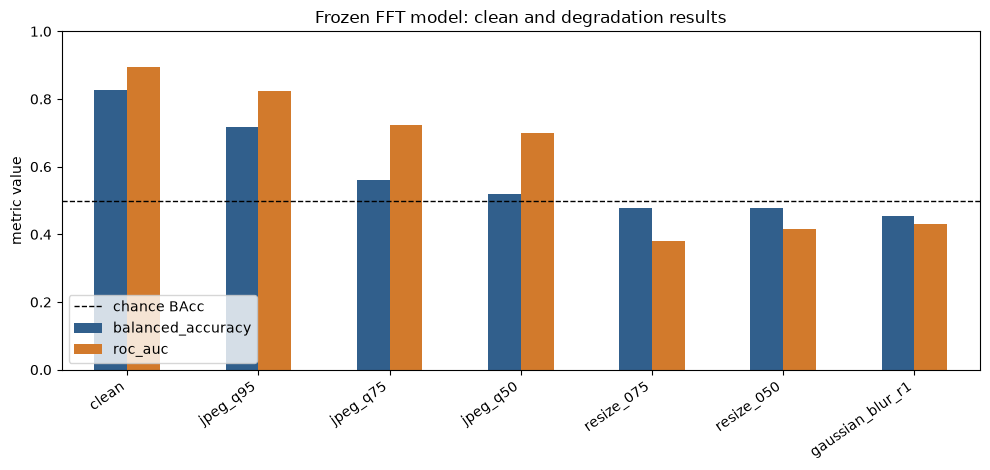

In [4]:
robustness = metrics.query("scope == 'all'").copy()
robustness['delta_bacc_from_clean'] = robustness['balanced_accuracy'] - clean.balanced_accuracy
display(robustness[[
    'condition', 'roc_auc', 'balanced_accuracy', 'macro_f1', 'fpr_at_tpr_95',
    'real_recall', 'ai_recall', 'delta_bacc_from_clean'
]])

ax = robustness.set_index('condition')[['balanced_accuracy', 'roc_auc']].plot(
    kind='bar', figsize=(10, 4.8), ylim=(0, 1), color=['#315f8c', '#d27a2c']
)
ax.axhline(0.5, color='black', linewidth=1, linestyle='--', label='chance BAcc')
ax.set_ylabel('metric value')
ax.set_xlabel('')
ax.set_title('Frozen FFT model: clean and degradation results')
ax.legend(loc='lower left')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()

## 4. Permitted conclusion and remaining external gate

On the specified DANI internal test, the frozen FFT model achieved ROC-AUC 0.8939 and balanced accuracy 0.8260. It generalised internally across parent-disjoint rows but remained generator-dependent. Its fixed operating point was highly sensitive to common post-processing: BAcc fell to 0.5186 for JPEG Q50, 0.4769 after 0.75× resize, 0.4786 after 0.50× resize, and 0.4538 after Gaussian blur. This falsifies any claim that the checkpoint is robust or deployment-ready.

No post-test tuning is permitted. Synthbuster + RAISE files were not locally materialised, so cross-dataset transfer remains **not evaluated**, not zero. The website must therefore remain a research shell unless a separately audited external evaluation changes the selection status to `frozen_external_validated`. A model score is not a calibrated probability and does not prove provenance.